In [1]:
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import infomap
from scipy.special import hyp2f1
from sklearn.metrics import adjusted_mutual_info_score

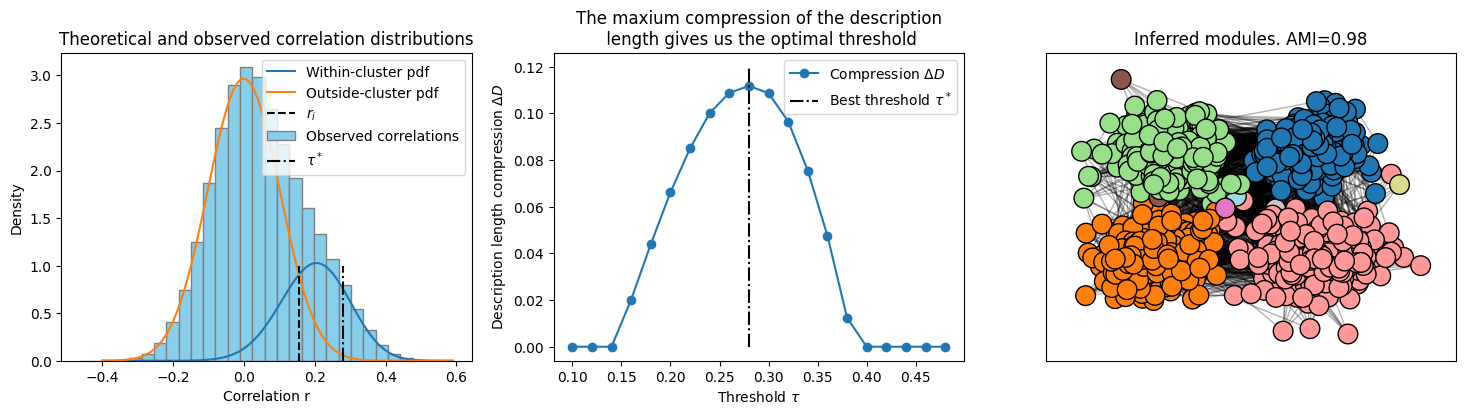

In [2]:
def compressionRegMapEq(tau_range, Sigma_hat):
    compression = np.full((len(tau_range), ), -0.1)
    modules = np.full((len(tau_range), ), -1)
    i = 0
    for tau in tau_range:
        #adj_matrix = np.abs(Sigma_hat * (Sigma_hat > tau)) # only positive correlations
        adj_matrix = np.abs(Sigma_hat * (np.abs(Sigma_hat) > tau)) # absolute value of correlation
        unweighted_matrix = (adj_matrix > 0).astype(int) # we use unweighted links since the Dirichlet prior is defined for these, but Infomap runs also with weighted links
        np.fill_diagonal(unweighted_matrix, 0) # avoid self links
        G = nx.from_numpy_matrix(unweighted_matrix)
        im = infomap.Infomap(two_level = True, regularized = True, silent = True) # regularized = True runs the Bayesian version
        im.add_networkx_graph(G)
        im.run()
        compression[i] = im.relative_codelength_savings if not np.isnan(im.relative_codelength_savings) else 0 # infomap returns nan if network has no links
        modules[i] = im.num_top_modules
        i+=1
    return compression, modules

def pdfHotelling(r, L, rho):
    factor1 = 1/np.sqrt(2*np.pi)*(L - 1)
    factor2 = (1 - rho**2)**(L / 2)
    factor3 = 1/np.sqrt(L) # gamma(n)/gamma(n + 1/2), this is a valid approx
    factor4 = (1 - rho*r)**(-L + 1/2)
    factor5 = hyp2f1(0.5, 0.5, L + 1/2, (rho*r+1)/2)
    pdf = factor1 * factor2 * factor3 * factor4 * factor5 * (1 - r**2)**((L - 3) / 2)
    return pdf

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize = (18,4))
N, q, rho = 1000, 4, 0.2
L = 100
nodesPerModule = int(N/q)
plantedPartition = []
for i in range(1,q+1):
    plantedPartition += np.full(nodesPerModule, i).tolist()

# block diagonal matrix to use as covariance matrix in multivariate normal distribution
block = np.full((nodesPerModule, nodesPerModule), rho)
np.fill_diagonal(block, 1)
cov =  np.block([[block if i==j else np.zeros((nodesPerModule, nodesPerModule)) for j in range(q)] for i in range(q)])
mean = np.zeros((q*nodesPerModule,))
# sample data and calculate the correlation
X = np.random.multivariate_normal(mean, cov, size=L)
X -= X.mean(axis=0)
X /= X.std(axis=0)
Sigma_hat = np.dot(X.T, X) / (L-1)
# plot the theoretical distribution and their intersection
r_range = np.arange(-0.4, 0.6, 0.01)
corr_dist_in = N/(N-1)*(1/q-1/N)*pdfHotelling(r_range, L, rho)
ax1.plot(r_range, corr_dist_in, label='Within-cluster pdf')
corr_dist_out =  N/(N-1)*(1-1/q)*pdfHotelling(r_range, L, 0.0)
ax1.plot(r_range, corr_dist_out, label='Outside-cluster pdf')
r_i = 1/rho - ((1-q/N)**(2/(2*L-3))*(1-rho**2)**((L-1)/(2*L-3)))/(rho*(q-1)**(2/(2*L-3)))
ax1.plot([r_i, r_i], [0, 1],'k--', label='$r_i$')
# extract upper triangle of correlations, excluding the diagonal
triu_indices = np.triu_indices_from(Sigma_hat, k=1)
corr_values = Sigma_hat[triu_indices]
# plot the distribution of observed correlations
ax1.hist(corr_values, bins=30, density = True, color='skyblue', edgecolor='gray', label = 'Observed correlations')
ax1.set_xlabel('Correlation r')
ax1.set_ylabel('Density')
ax1.set_title('Theoretical and observed correlation distributions')
# use the Regularized Map Equation to find the best threshold on correlations
tau_range = np.arange(0.1, 0.5, 0.02) # set of thresholds to try
comp, mods = compressionRegMapEq(tau_range, Sigma_hat) # calculate compression and number of modules as function of threshold
tau = np.round(tau_range[np.argmax(comp)], 2) # best threshold at max compression
# plot the best threshold
ax1.plot([tau, tau], [0, 1],'k-.', label=r'$\tau^*$')
ax1.legend()
# plot the description length compression as function of threshold
ax2.plot(tau_range, comp, 'o-', label='Compression $\Delta D$')
ax2.plot([tau, tau], [0, 0.12],'k-.', label=r'Best threshold $\tau^*$')
ax2.set_xlabel(r'Threshold $\tau$')
ax2.set_ylabel('Description length compression $\Delta D$')
ax2.legend()
ax2.set_title('The maxium compression of the description\n length gives us the optimal threshold')

# get the best-threshold network and its modules
#adj_matrix = np.abs(Sigma_hat * (Sigma_hat > tau))
adj_matrix = np.abs(Sigma_hat * (np.abs(Sigma_hat) > tau)) # absolute value of correlation
unweighted_matrix = (adj_matrix > 0).astype(int)
np.fill_diagonal(unweighted_matrix, 0)
G = nx.from_numpy_matrix(unweighted_matrix)
im = infomap.Infomap(two_level = True, regularized = True, silent = True, num_trials = 1) # increase num_trials if result varies between runs
im.add_networkx_graph(G)
im.run()
# add the modules as attribute in the network
modules = dict(im.modules)
node_names = list(G.nodes())
module_dict_IM = {node_names[i]: modules[i] for i in list(range(len(G.nodes())))}
nx.set_node_attributes(G, module_dict_IM, 'module') # add the node's module as network attribute
#nx.write_gexf(G, 'test.gexf') # write a gexf file for plotting in eg Gephi
# plot the network
modules = nx.get_node_attributes(G, 'module')
node_colors = [modules[node] for node in G.nodes()]
cmap = mpl.colormaps['tab20']
pos = nx.spring_layout(G)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap=cmap, node_size=200, edgecolors="black", ax=ax3)
nx.draw_networkx_edges(G, pos, alpha=0.3, ax=ax3)
AMI = adjusted_mutual_info_score(node_colors, plantedPartition)
ax3.set_title(f'Inferred modules. AMI={AMI:.2f}');